### Versão do Python

In [1]:
import sys
print(sys.version)

3.11.14 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 18:30:03) [MSC v.1929 64 bit (AMD64)]


### Exportando requirements.txt

In [2]:
!pip freeze > requirements.txt

### Instalação da biblioteca Kaggle

In [3]:
!pip install kaggle

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


### Lendo chave da API do Kaggle

In [4]:
import os
import json

# Obtém o diretório atual do notebook
current_dir = os.getcwd()

# Junta o diretório atual com o nome do arquivo kaggle.json
# Garantir que o arquivo kaggle.json esteja no mesmo diretório do notebook

kaggle_json_path = os.path.join(current_dir, "kaggle.json")

print(f"Caminho do kaggle.json (relativo ao notebook): {kaggle_json_path}")

#Leia as credenciais do arquivo (o restante do seu código)
try:
    with open(kaggle_json_path, 'r') as f:
        data = json.load(f)
        
    os.environ['KAGGLE_USERNAME'] = data['username']
    os.environ['KAGGLE_KEY'] = data['key']
    
    print("Credenciais do Kaggle configuradas com sucesso!")
    
except FileNotFoundError:
    print(f"Erro: O arquivo kaggle.json não foi encontrado em {kaggle_json_path}")



Caminho do kaggle.json (relativo ao notebook): c:\Projetos\especializacao_ia\sexto_modulo_clusterizacao\kaggle.json
Credenciais do Kaggle configuradas com sucesso!


### Bibliotecas utilizadas no projeto

In [5]:
from kaggle.api.kaggle_api_extended import KaggleApi
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import math
import random
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import cdist
from sklearn.metrics import pairwise_distances
from sklearn.metrics import pairwise_distances_argmin_min
from sklearn.cluster import DBSCAN

### Baixando Dataset unsupervised-learning-on-country-data diretamente da api do Kaggle

In [6]:

#Cria uma instância da API
api = KaggleApi()

#Autentiqua usando as variáveis de ambiente (configuradas na Célula 2)
api.authenticate()

#Defina o identificador do dataset
dataset_id = 'rohan0301/unsupervised-learning-on-country-data'
download_path = '.'

print(f"Baixando o dataset {dataset_id}...")

#Execute o download
# unzip=True fará com que o arquivo .zip seja automaticamente descompactado
api.dataset_download_files(dataset_id, path=download_path, unzip=True)

print("\nDownload e descompactação concluídos!")

Baixando o dataset rohan0301/unsupervised-learning-on-country-data...
Dataset URL: https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data

Download e descompactação concluídos!


In [7]:
df = pd.read_csv('Country-data.csv')
df.head()

df.info()   


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [8]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


## Análise do Dataset

 


### **Descrição das Variáveis**

* **country:** Nome do país.
* **child_mort:** Mortes de crianças menores de 5 anos por 1.000 nascidos vivos.
* **exports:** Exportações de bens e serviços (% do PIB per capita).
* **health:** Gastos totais em saúde (% do PIB per capita).
* **imports:** Importações de bens e serviços (% do PIB per capita).
* **income:** Renda líquida per capita (USD).
* **inflation:** Taxa anual de crescimento do PIB (%).
* **life_expec:** Expectativa de vida ao nascer (anos).
* **total_fer:** Número médio de filhos por mulher.
* **gdpp:** PIB per capita (USD).

 



#### **Quantidade de Países Únicos**

In [9]:
df['country'].nunique()

167

## **Faixa Dinâmica de Valores em Cada Coluna Numérica do Dataset**

Antes da etapa de **clusterização**, é fundamental realizar uma **análise e pré-processamento dos dados**.
Essa etapa garante que as variáveis estejam em um **formato e escala adequados** para os algoritmos de agrupamento.

Na análise realizada, observamos:

* Muitos **outliers** em diversas features.
* Falta de **padronização de escala** entre as variáveis.

Por isso, optou-se por **exibir o boxplot individual por feature** nesta fase.
Após o pré-processamento, será possível **visualizar todas as features em uma mesma escala**.

---

## **Etapas Fundamentais antes da Clusterização**

### 1. **Limpeza dos Dados**

* Remover ou imputar valores ausentes.
* Eliminar duplicatas.
* Corrigir inconsistências, como **erros de digitação ou formatação**.

---

### 2. **Seleção e Transformação de Variáveis**

* Escolher as **features mais relevantes** para o problema.
* Converter variáveis categóricas em numéricas (ex.: **One-Hot Encoding**).
* Se necessário, aplicar técnicas de **redução de dimensionalidade**, como **PCA**.

---

### 3. **Normalização ou Padronização**

* Escalar os dados para que todas as variáveis tenham **influência equivalente na distância**.
* Exemplos de técnicas:

  * **StandardScaler**
  * **RobustScaler**
  * **MinMaxScaler**

---

### 4. **Tratamento de Outliers**

* Esta etapa é necessária, mas pode ser **problemática**.
* Manter outliers pode prejudicar o desenvolvimento do modelo, mas **removê-los sem critério também pode ser um erro**.
* A decisão depende do **objetivo final do negócio**.

---

### 5. **Verificação da Distribuição dos Dados**

* Analisar a distribuição das features é fundamental antes de aplicar qualquer modelo de machine learning.
* Alguns tipos de dados são mais adequados para certos modelos:

  * Exemplo: datasets semelhantes ao **make_moons** do Sklearn não são ideais para **K-Means**.
* Essa análise permite **entender melhor o problema** e **selecionar o modelo mais eficiente**.



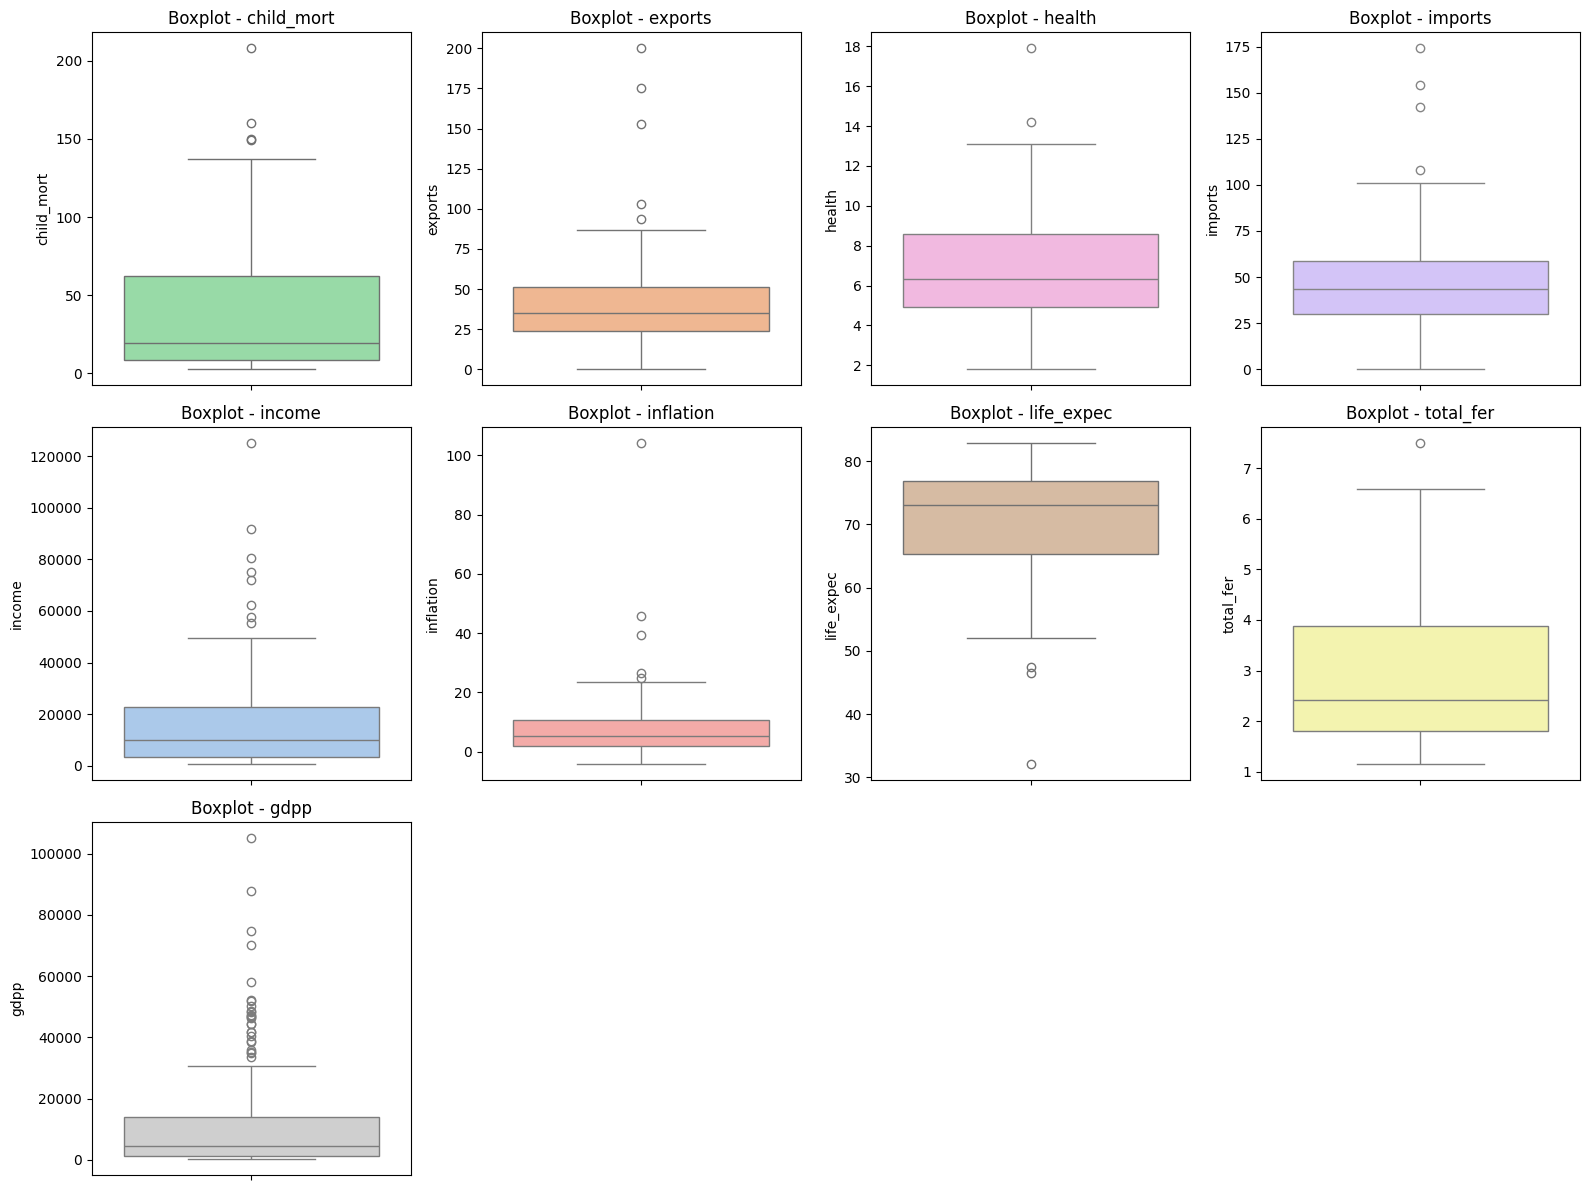

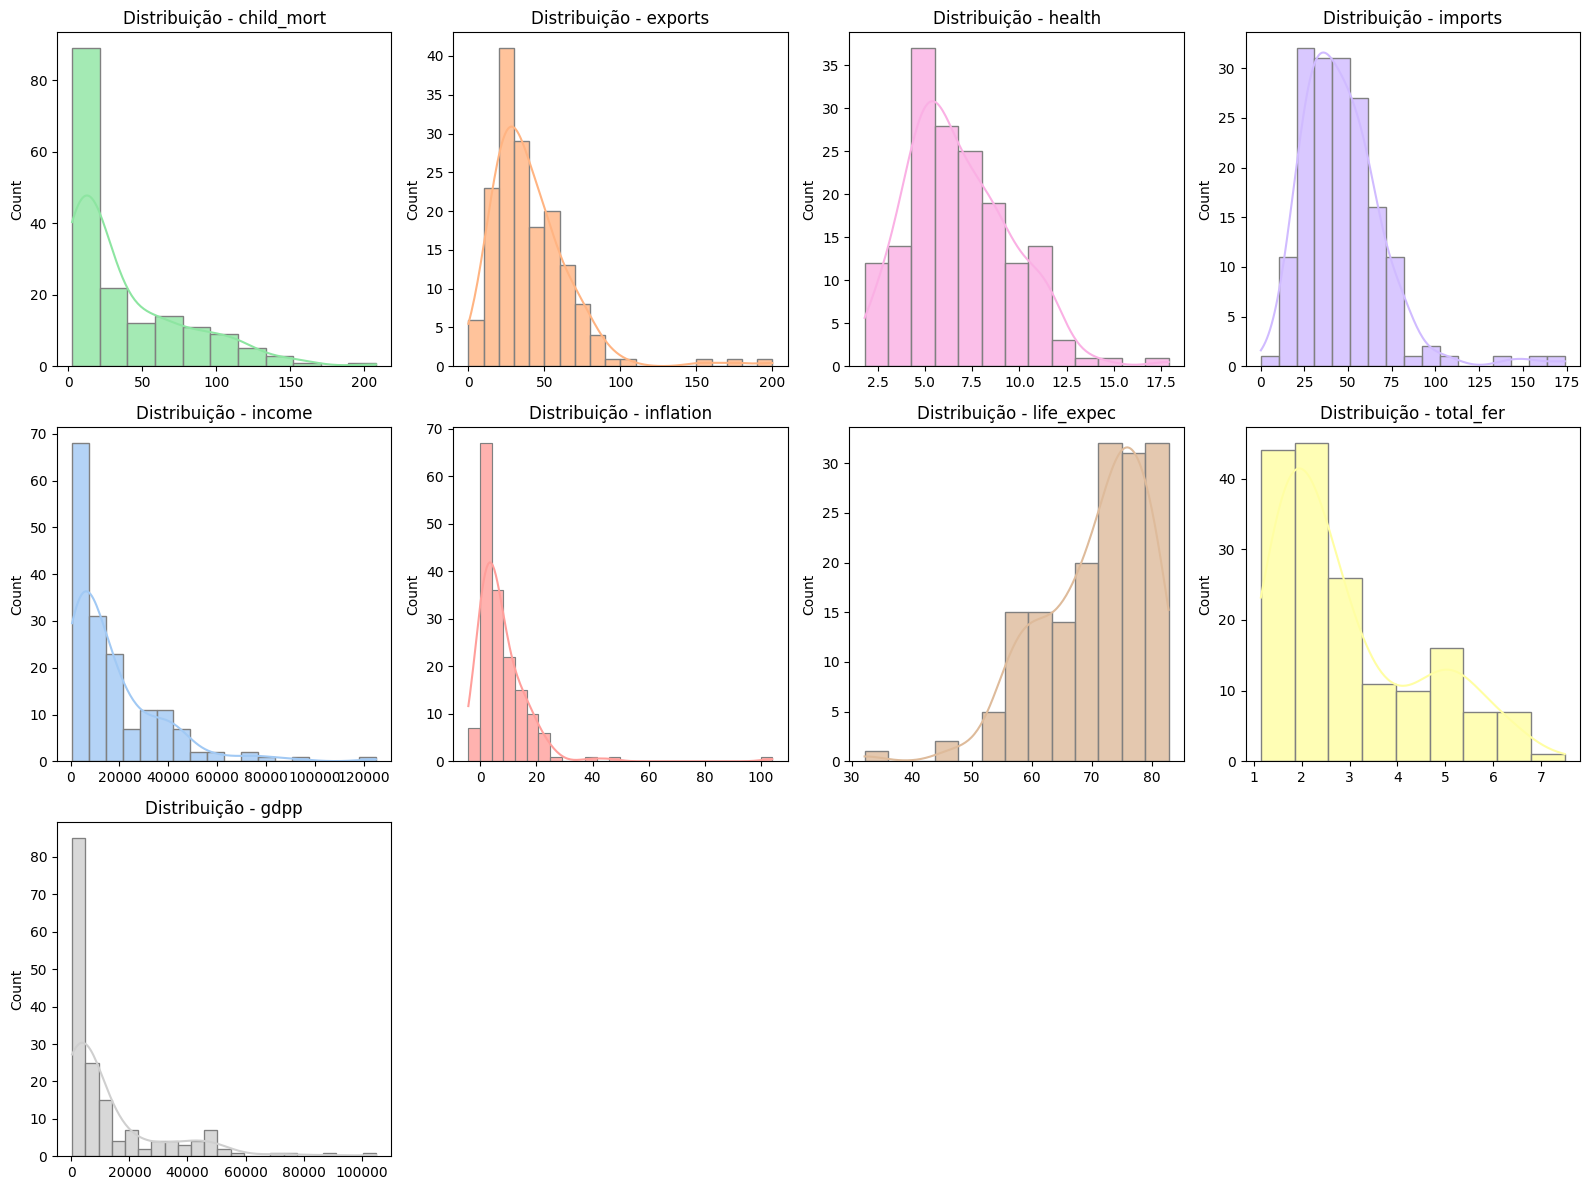

C:\Users\Bruno Adalberto\AppData\Roaming\Python\Python311\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
C:\Users\Bruno Adalberto\AppData\Roaming\Python\Python311\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
C:\Users\Bruno Adalberto\AppData\Roaming\Python\Python311\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
C:\Users\Bruno Adalberto\AppData\Roaming\Python\Python311\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
C:\Users\Bruno Adalberto\AppData\Roaming\Python\Python311\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigne

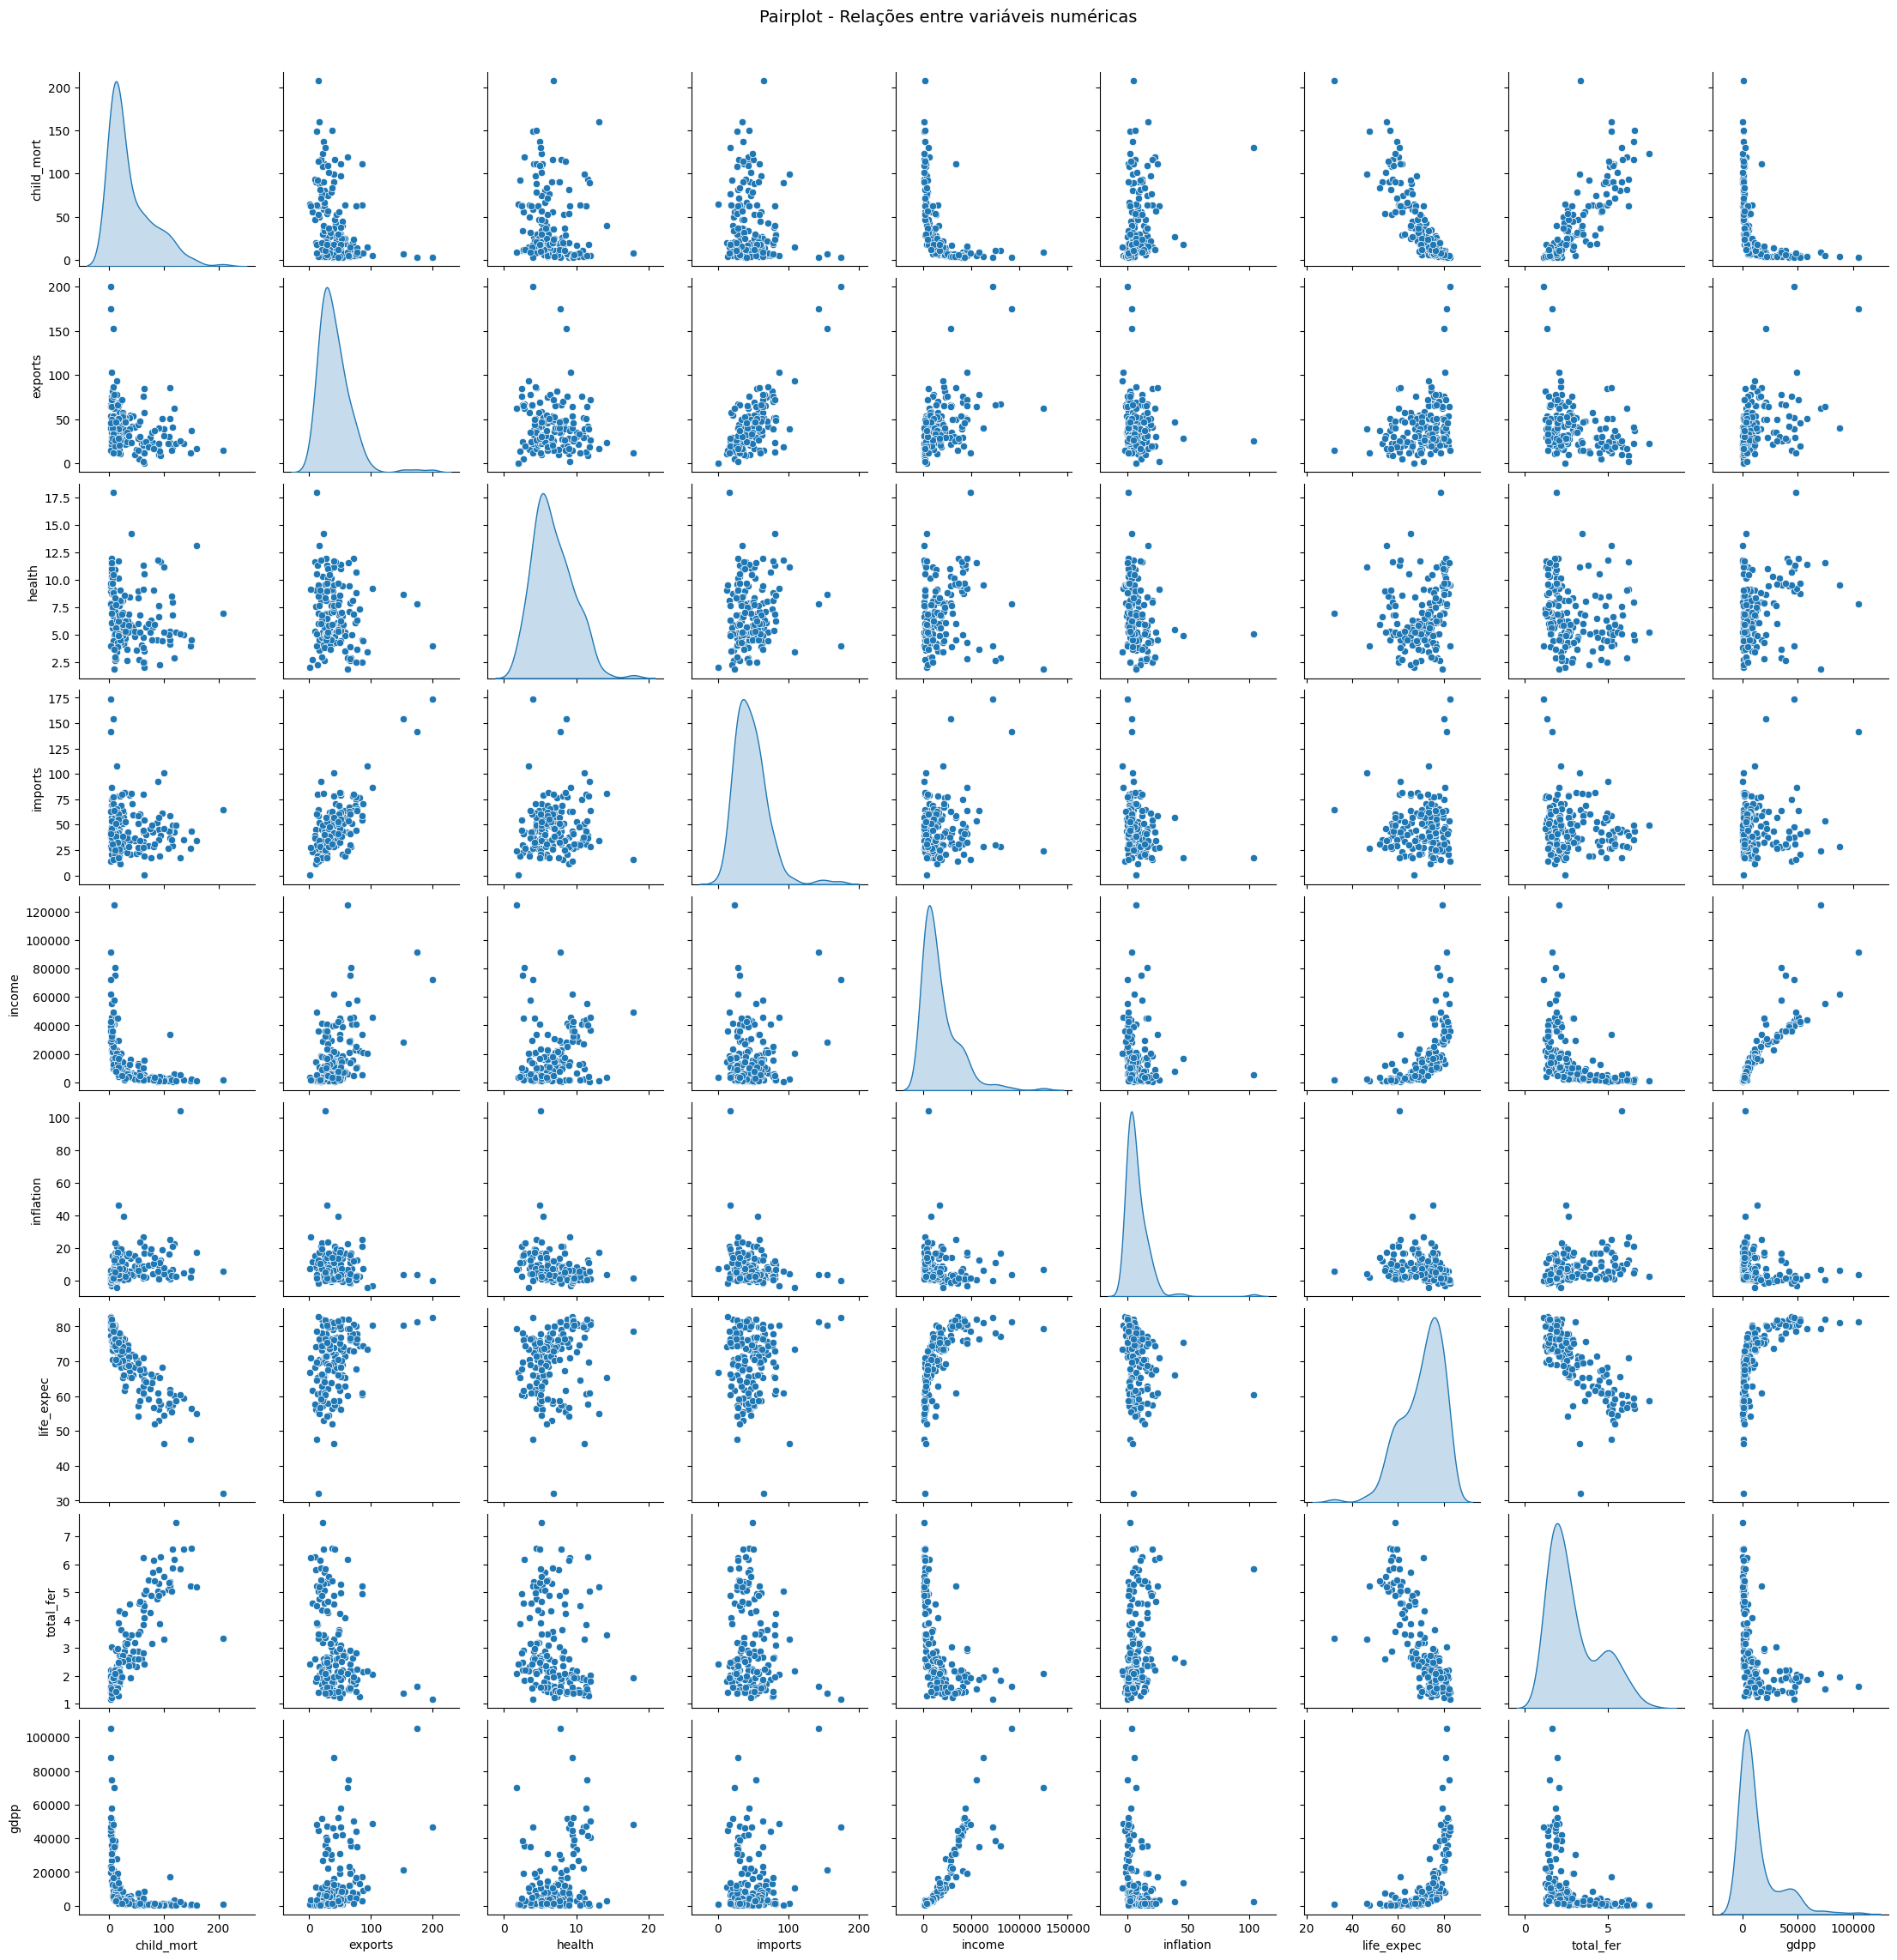

In [10]:
# Seleciona colunas numéricas
cols = df.select_dtypes(include=['float64', 'int64']).columns
n = len(cols)

# Grid de subplots
n_cols = 4
n_rows = math.ceil(n / n_cols)

# Paleta de cores suaves (pastel tones)
palette = sns.color_palette("pastel", n)
random.shuffle(palette)  # embaralha para variar as cores entre execuções

# Boxplots verticais
# ========================
plt.figure(figsize=(16, 4*n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    color = palette[i-1]
    sns.boxplot(y=df[col], color=color)  # vertical (em pé)
    plt.title(f'Boxplot - {col}')
    plt.xlabel('')
    plt.tight_layout()

plt.show()

# Histogramas com KDE
# ========================
plt.figure(figsize=(16, 4*n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    color = palette[i-1]
    sns.histplot(df[col], kde=True, color=color, edgecolor='gray', alpha=0.8)
    plt.title(f'Distribuição - {col}')
    plt.xlabel('')
    plt.tight_layout()

plt.show()

num_df = df.select_dtypes(include=['float64', 'int64'])
# Pairplot completo
sns.pairplot(num_df, diag_kind="kde", palette="tab10")

plt.suptitle("Pairplot - Relações entre variáveis numéricas", y=1.02, fontsize=14)
plt.show()


Valores ausentes por coluna:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Registros duplicados: 0

Shape após remoção de 'country': (167, 9)

Estatísticas após padronização:
            count          mean       std       min       25%       50%  \
child_mort  167.0 -3.722904e-17  1.003008 -0.887138 -0.746619 -0.471798   
exports     167.0  2.127373e-16  1.003008 -1.500192 -0.633337 -0.223528   
health      167.0  5.504579e-16  1.003008 -1.827827 -0.692211 -0.181001   
imports     167.0  2.765585e-16  1.003008 -1.939940 -0.691479 -0.148743   
income      167.0 -7.977650e-17  1.003008 -0.860326 -0.717456 -0.373808   
inflation   167.0 -1.063687e-17  1.003008 -1.137852 -0.566641 -0.226950   
life_expec  167.0  3.696311e-16  1.003008 -4.337186 -0.592758  0.286958   
total_fer   167.0  3.044803e-16  1.003008 -1.191250 -0.763902 -0.356431   
gdpp        167.0  5.

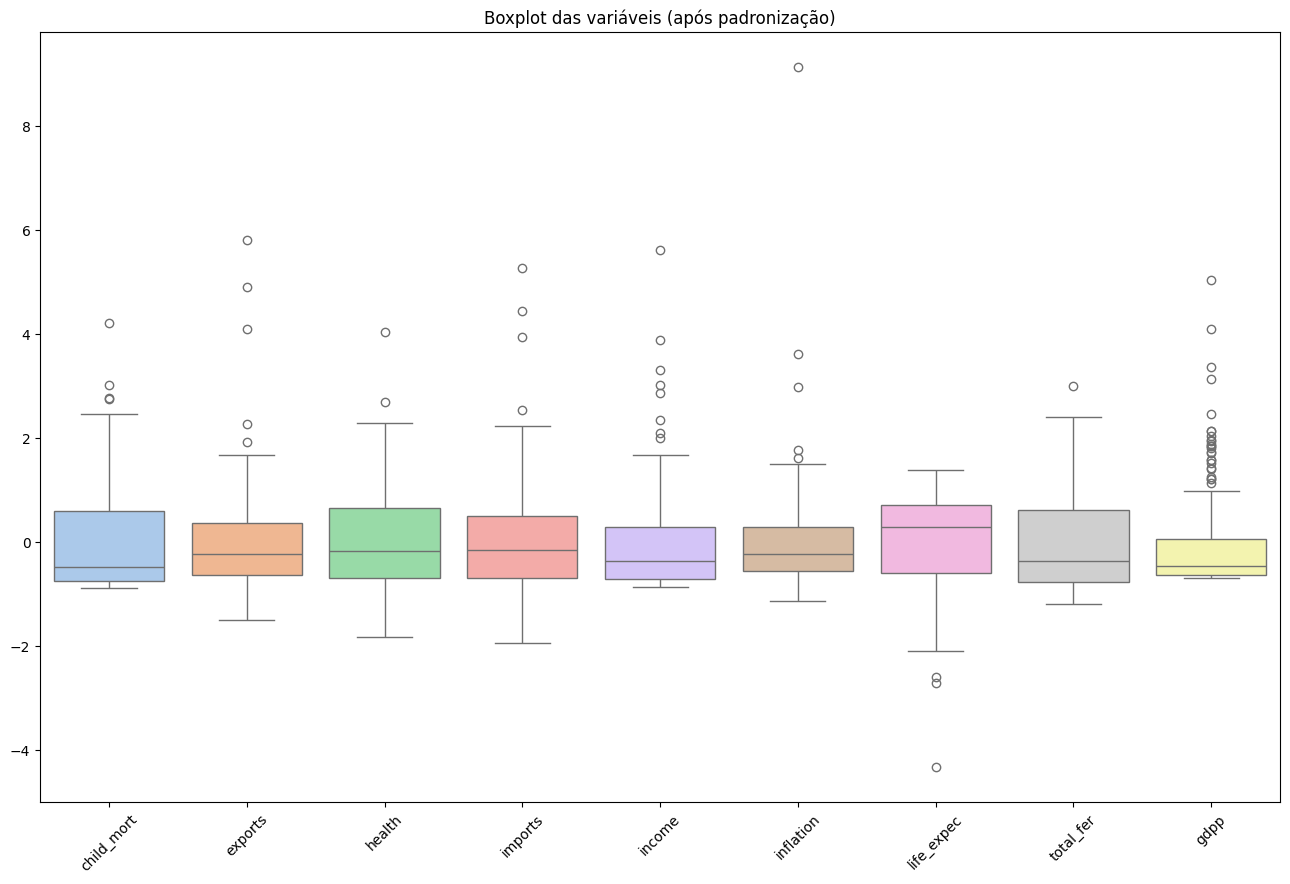

In [11]:
# Verifica se há valores ausentes ou duplicados
print("\nValores ausentes por coluna:")
print(df.isnull().sum())

print("\nRegistros duplicados:", df.duplicated().sum())


df_num = df.drop(columns=['country'])
print("\nShape após remoção de 'country':", df_num.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_num)

# Converte para DataFrame novamente
df_scaled = pd.DataFrame(X_scaled, columns=df_num.columns)

print("\nEstatísticas após padronização:")
print(df_scaled.describe().T)


# =======================================================
# Visualização após o scaling
# =======================================================
plt.figure(figsize=(16, 10))
sns.boxplot(data=df_scaled, palette="pastel")
plt.xticks(rotation=45)
plt.title("Boxplot das variáveis (após padronização)")
plt.show()

### K-Médias (K-Means)

In [12]:
X = df_scaled.copy()

# Modelo com 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X)

df['Cluster_KMeans'] = kmeans.labels_
print(df['Cluster_KMeans'].value_counts())

perfil = df.groupby('Cluster_KMeans').mean(numeric_only=True).round(2)
print(perfil)

Cluster_KMeans
2    84
1    47
0    36
Name: count, dtype: int64
                child_mort  exports  health  imports    income  inflation  \
Cluster_KMeans                                                              
0                     5.00    58.74    8.81    51.49  45672.22       2.67   
1                    92.96    29.15    6.39    42.32   3942.40      12.02   
2                    21.93    40.24    6.20    47.47  12305.60       7.60   

                life_expec  total_fer      gdpp  
Cluster_KMeans                                   
0                    80.13       1.75  42494.44  
1                    59.19       5.01   1922.38  
2                    72.81       2.31   6486.45  


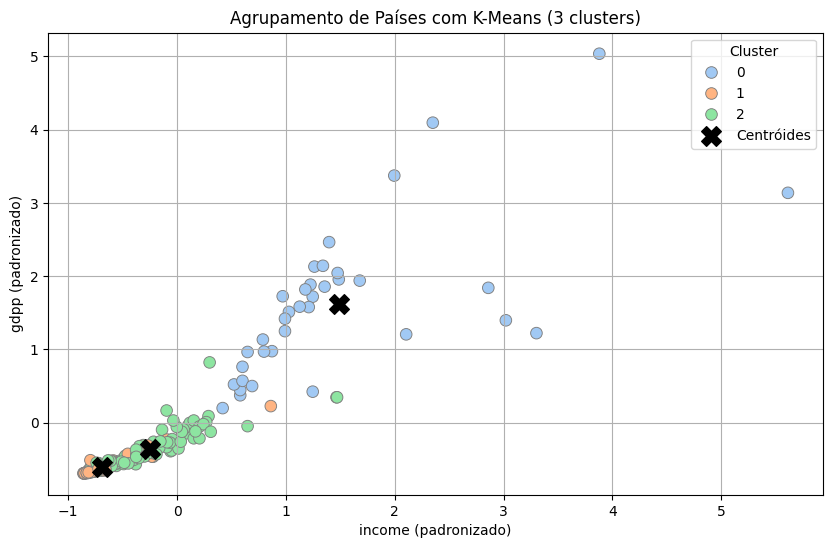

In [13]:
# Escolhe duas variáveis relevantes (sociais e econômicas)
x_var = 'income'
y_var = 'gdpp'

# Dados originais (padronizados)
X_plot = df_scaled[[x_var, y_var]]

# Labels do K-Means
labels = kmeans.labels_

# Centróides nas mesmas duas dimensões
centers = kmeans.cluster_centers_

# Plot
plt.figure(figsize=(10,6))
sns.scatterplot(x=X_plot[x_var], y=X_plot[y_var],
                hue=labels, palette='pastel', s=70, edgecolor='gray')

# Marca os centróides com X grandes
plt.scatter(centers[:, df_scaled.columns.get_loc(x_var)],
            centers[:, df_scaled.columns.get_loc(y_var)],
            marker='X', s=200, c='black', label='Centróides')

# Personalização
plt.title("Agrupamento de Países com K-Means (3 clusters)")
plt.xlabel(f"{x_var} (padronizado)")
plt.ylabel(f"{y_var} (padronizado)")
plt.legend(title="Cluster", loc='best')
plt.grid(True)
plt.show()

In [14]:
# Distâncias dos países aos centróides
distances = cdist(X, kmeans.cluster_centers_)

# País mais próximo do centróide de cada cluster
for i in range(3):
    idx = np.argmin(distances[:, i])
    country = df.iloc[idx]['country']
    print(f"Cluster {i}: país mais representativo -> {country}")


Cluster 0: país mais representativo -> Iceland
Cluster 1: país mais representativo -> Guinea
Cluster 2: país mais representativo -> Jamaica


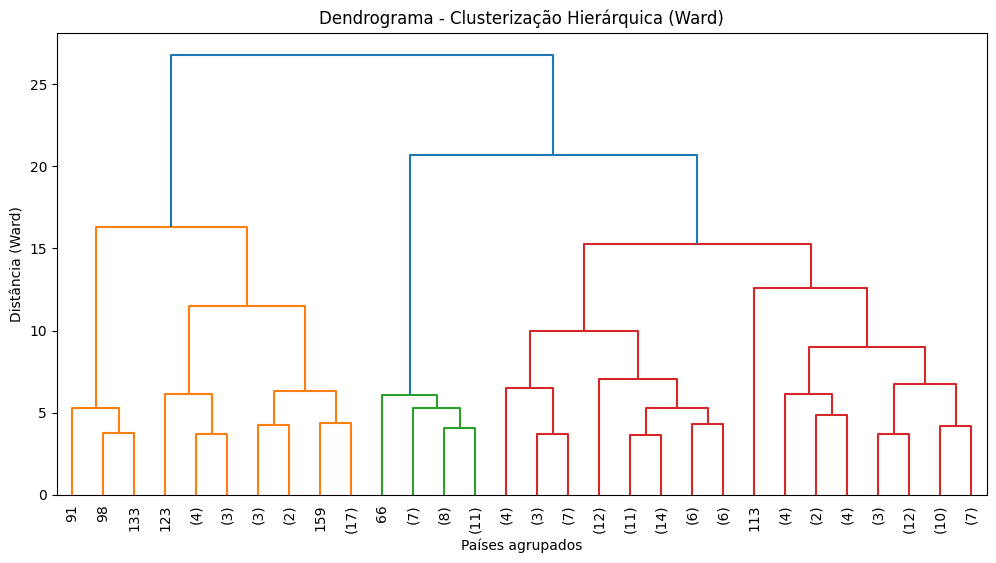

In [15]:
plt.figure(figsize=(12, 6))
Z = linkage(X, method='ward', metric='euclidean')
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10.)
plt.title("Dendrograma - Clusterização Hierárquica (Ward)")
plt.xlabel("Países agrupados")
plt.ylabel("Distância (Ward)")
plt.show()


In [16]:
df['Cluster_Hierarquico'] = fcluster(Z, t=3, criterion='maxclust')
print(df['Cluster_Hierarquico'].value_counts())


perfil_hierarquico = df.groupby('Cluster_Hierarquico').mean(numeric_only=True).round(2)
print(perfil_hierarquico)

Cluster_Hierarquico
3    106
1     34
2     27
Name: count, dtype: int64
                     child_mort  exports  health  imports    income  \
Cluster_Hierarquico                                                   
1                          5.96    58.51    8.50    48.90  47588.24   
2                        105.07    23.59    6.51    39.66   1589.74   
3                         31.62    39.99    6.35    48.09  11341.89   

                     inflation  life_expec  total_fer      gdpp  \
Cluster_Hierarquico                                               
1                         4.12       79.98       1.89  43170.59   
2                         7.14       57.25       5.43    667.89   
3                         9.12       70.92       2.65   6407.37   

                     Cluster_KMeans  
Cluster_Hierarquico                  
1                              0.18  
2                              1.00  
3                              1.72  


# Análise de Clusters – Indicadores Socioeconômicos

## **Cluster 0 – Países Desenvolvidos**

**País mais representativo (próximo ao centróide):**

* **K-means:** Iceland (Islândia)
* **Hierárquico:** Iceland (Polônia)

**Dados (K-means | Hierárquico):**

* **Mortalidade infantil (child_mort):** 5 | 5,96
* **Renda per capita (income):** 45.672 | 47.588
* **Expectativa de vida (life_expec):** 80,13 anos | 79,98 anos
* **Número de filhos por mulher (total_fer):** 1,75 | 1,89
* **Inflação (inflation):** 2,67% | 4,12%
* **Exportações (exports):** 58,74% do PIB | 58,51%
* **Importações (imports):** 51,49% do PIB | 48,90%
* **Investimento em saúde (health):** 8,81% do PIB | 8,50%
* **PIB per capita (gdpp):** 42.494 | 43.170

**Análise:**
Este grupo representa **países desenvolvidos**, com economias estáveis e qualidade de vida elevada.
A baixa fertilidade e mortalidade infantil refletem **avanços sociais e sanitários**, enquanto o alto PIB per capita e o equilíbrio comercial indicam **economias maduras**.
A **Islândia** representa muito bem o centróide do grupo, refletindo médias socioeconômicas típicas de nações de **altíssimo desenvolvimento humano**, com **qualidade de vida elevada**, **economia estável** e **forte inserção internacional**.

---

## **Cluster 1 – Países em Vulnerabilidade Socioeconômica**

**País mais representativo (próximo ao centróide):**

* **K-means:** Guinea (Guiné)
* **Hierárquico:** Ghana (Gana)

**Dados (K-means | Hierárquico):**

* **Mortalidade infantil (child_mort):** 92,96 | 105,07
* **Renda per capita (income):** 3.942 | 1.589
* **Expectativa de vida (life_expec):** 59,19 anos | 57,25 anos
* **Fertilidade (total_fer):** 5,01 | 5,43
* **Inflação (inflation):** 12,02% | 7,14%
* **Exportações (exports):** 29,15% do PIB | 23,59%
* **Importações (imports):** 42,32% do PIB | 39,66%
* **Investimento em saúde (health):** 6,39% do PIB | 6,51%
* **PIB per capita (gdpp):** 1.922 | 668

**Análise:**
Os países deste grupo apresentam **baixo desenvolvimento humano e econômico**.
A combinação de **alta mortalidade**, **alta fertilidade** e **baixa renda** indica **vulnerabilidade estrutural**, com **economias dependentes**, **baixo investimento em capital humano** e **infraestrutura limitada**.
A **Guiné** exemplifica essa realidade, sendo o ponto mais próximo do centróide de países de **baixa renda e forte vulnerabilidade social**.

---

## **Cluster 2 – Economias Emergentes / em Transição**

**País mais representativo (próximo ao centróide):**

* **K-means:** Jamaica
* **Hierárquico:** Kiribati

**Dados (K-means | Hierárquico):**

* **Mortalidade infantil (child_mort):** 21,93 | 31,62
* **Exportações (exports):** 40,24% do PIB | 39,99%
* **Investimento em saúde (health):** 6,20% do PIB | 6,35%
* **Importações (imports):** 47,47% do PIB | 48,09%
* **Renda per capita (income):** 12.305 | 11.342
* **Inflação (inflation):** 7,60% | 9,12%
* **Expectativa de vida (life_expec):** 72,81 anos | 70,92 anos
* **Fertilidade (total_fer):** 2,31 filhos/mulher | 2,65 filhos/mulher
* **PIB per capita (gdpp):** 6.486 | 6.407

**Análise:**
Este grupo reúne **países emergentes**, em **processo de crescimento econômico** e **estabilização social**.
Os níveis intermediários de renda, mortalidade e expectativa de vida refletem **avanços em relação aos países vulneráveis**, embora persistam **desigualdades** e **inflação acima do ideal**.
A **Jamaica** é representativa desse estágio de **transição**, com progresso em **saúde e educação**, mas ainda enfrentando **desafios estruturais e econômicos típicos** de economias em desenvolvimento.

 


## **Comparação entre os Métodos de Agrupamento**

Ambos os métodos identificaram **três grupos socioeconômicos principais**, com perfis muito semelhantes, conforme descrito anteriormente.
Entretanto, algumas diferenças e características metodológicas podem ser observadas:

---

### **1. Tamanho dos Grupos (Quantidade de Países por Cluster)**

* **K-Means:** formou grupos mais equilibrados — **36**, **47** e **84 países**.
* **Hierárquico (Ward):** formou um grupo **maior (106 países)**, um **médio (34)** e um **menor (27)**, mostrando uma **fusão mais ampla de países com características intermediárias**.

---

### **2. Sensibilidade ao Método de Agrupamento**

* **K-Means:**

  * Utiliza o critério de **minimização da distância média aos centróides**,
  * Tendendo a criar **grupos de formato mais esférico e homogêneo**.

* **Hierárquico (Ward):**

  * Baseia-se em **fusões sucessivas** entre países,
  * Proporcionando uma **visão hierárquica das similaridades**, útil para identificar **proximidades e subgrupos** no **dendrograma**.

---

### **3. Composição Exata dos Grupos**

* Apesar dos **perfis médios semelhantes**, alguns **países limítrofes** (em situação intermediária) **migraram de cluster** entre os métodos.
* Isso ocorre porque:

  * O **K-Means** “**força**” partições fixas;
  * O **Hierárquico** considera a **estrutura de semelhança global** dos dados, permitindo transições mais naturais entre grupos.

---

### **4. Proximidade entre Métodos (Validação Cruzada)**

* A correspondência entre os clusters é **alta**, conforme indica a **média da variável `Cluster_KMeans`** dentro dos grupos hierárquicos:
  ≈ **0.18**, **1.00** e **1.72**.
* Isso evidencia **consistência estrutural** entre os dois modelos — ou seja, **ambos chegaram praticamente às mesmas fronteiras de agrupamento**.

---

### **5. Considerações Finais**

* O **método hierárquico** oferece uma **visão mais interpretável e visual**, especialmente por meio do **dendrograma**.
* O **K-Means**, por sua vez, é **mais direto e eficiente computacionalmente**.
* Em conjunto, ambos confirmam a **robustez da análise** e a **validade dos agrupamentos**, evidenciando **padrões globais coerentes de desigualdade e desenvolvimento**.

 


In [17]:
# número de clusters
k = 3

# seleção inicial dos medóides aleatórios
np.random.seed(42)
medoids_idx = np.random.choice(len(X), k, replace=False)
medoids = X.iloc[medoids_idx]

# função auxiliar para atribuir cada ponto ao medóide mais próximo
def assign_points(X, medoids):
    distances = pairwise_distances(X, medoids)
    return np.argmin(distances, axis=1)

# atribuição inicial
labels = assign_points(X, medoids)

max_iter = 100
for iteration in range(max_iter):
    new_medoids = medoids.copy()
    for i in range(k):
        cluster_points = X.iloc[labels == i]
        if len(cluster_points) == 0:
            continue
        intra_distances = pairwise_distances(cluster_points)
        total_distances = intra_distances.sum(axis=1)
        best_idx = np.argmin(total_distances)
        new_medoids.iloc[i] = cluster_points.iloc[best_idx]
    
    new_labels = assign_points(X, new_medoids)
    
    # verificar convergência
    if np.all(new_medoids.values == medoids.values):
        print(f"Convergência alcançada na iteração {iteration+1}")
        break

    medoids = new_medoids
    labels = new_labels

print("\nMedóides finais encontrados!\n")

# associar cada país ao cluster final
df['Cluster_Medoid'] = labels

# mostrar quantos países por grupo
print("Distribuição dos clusters:\n")
print(df['Cluster_Medoid'].value_counts(), "\n")

# mostrar os países que são os medóides finais
print("País representativo (medóide) de cada cluster:\n")
for i in range(k):
    # país cujo vetor é igual ao medóide final
    distances = pairwise_distances(X, [medoids.iloc[i]])
    idx_country = np.argmin(distances)
    country_name = df.iloc[idx_country]['country']
    print(f"Cluster {i}: {country_name}")


Convergência alcançada na iteração 3

Medóides finais encontrados!

Distribuição dos clusters:

Cluster_Medoid
2    96
1    62
0     9
Name: count, dtype: int64 

País representativo (medóide) de cada cluster:

Cluster 0: Kiribati
Cluster 1: Ghana
Cluster 2: Poland


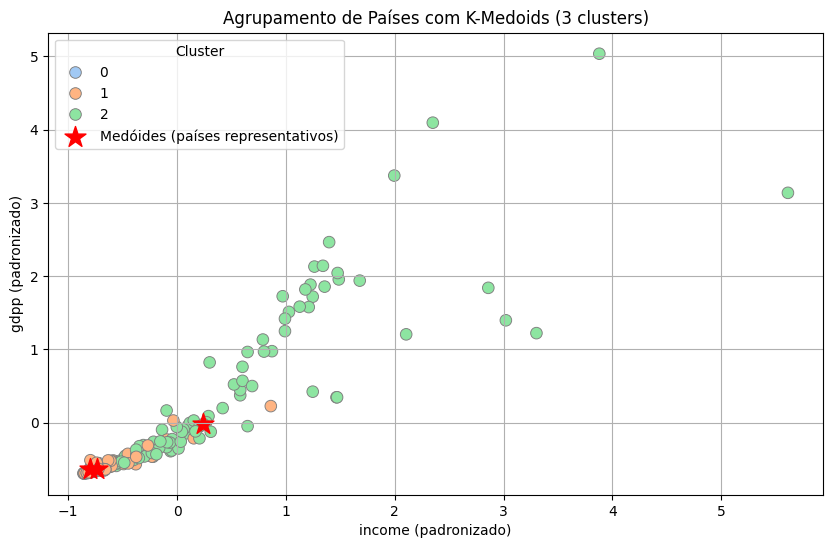

In [18]:
 
#Escolhe duas variáveis para o gráfico 
x_var = 'income'
y_var = 'gdpp'

#Cria um DataFrame com os dados padronizados nessas duas variáveis
X_plot = df_scaled[[x_var, y_var]]

#Rótulos do K-Medoids
labels = df['Cluster_Medoid']

#Índices dos medóides (países representantes)
medoid_points = medoids[[x_var, y_var]]

#Cria o gráfico
plt.figure(figsize=(10,6))
sns.scatterplot(
    x=X_plot[x_var], 
    y=X_plot[y_var],
    hue=labels,
    palette='pastel',
    s=70,
    edgecolor='gray'
)

# Adiciona os medóides com estrelas vermelhas
plt.scatter(
    medoid_points[x_var],
    medoid_points[y_var],
    marker='*',
    s=250,
    c='red',
    label='Medóides (países representativos)'
)

# Personaliza o gráfico
plt.title("Agrupamento de Países com K-Medoids (3 clusters)")
plt.xlabel(f"{x_var} (padronizado)")
plt.ylabel(f"{y_var} (padronizado)")
plt.legend(title="Cluster", loc='best')
plt.grid(True)
plt.show()


## **Centroide vs. Medoide**

### **Diferença Conceitual**

* **Centroide:**

  * Representa a **média matemática** dos pontos de um cluster.
  * **Não precisa ser um dado real**; pode gerar um ponto “virtual” que não corresponde a nenhum país real.

* **Medoide:**

  * É **um dado real do conjunto**, escolhido como o ponto central do cluster.
  * Ao selecionar um país como **baricentro (medoide)**, fixamos um **país real** como referência do grupo.

---

### **Observações sobre o K-Medoids**

* O **K-Medoids** apresentou uma **distribuição de clusters significativamente desigual**: **96, 62, 9**.

  * Isso indica que a **maior parte dos países** foi considerada **similar o suficiente** para pertencer ao mesmo grupo.
  * Apenas um **pequeno conjunto de países** destacou-se por possuir **características muito diferentes da média**.

* **Vantagens do K-Medoids:**

  * Facilita a **interpretação**, pois os **centros são países reais** (ex.: Gana, Polônia e Kiribati).

* **Limitação:**

  * Tendência a formar **grupos desbalanceados** quando há **sobreposição entre classes socioeconômicas**, já que os clusters se ajustam aos pontos reais mais representativos.
 


In [19]:
# Aplica o DBSCAN com os parâmetros ajustados
dbscan = DBSCAN(eps=1.2, min_samples=4, metric='euclidean')
dbscan.fit(X_scaled)

# Cria coluna de cluster
df['Cluster_DBSCAN'] = dbscan.labels_

# Conta e ordena os clusters do menor para o maior
cluster_counts = df['Cluster_DBSCAN'].value_counts().sort_values(ascending=True)

print("\n Distribuição dos clusters (ordenado do menor para o maior):")
print(cluster_counts)

# Mostra número total de clusters válidos
n_clusters = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)
print(f"\nNúmero de clusters detectados (sem contar ruído): {n_clusters}")

# Mostra quantos países foram considerados ruído
outliers = list(df['Cluster_DBSCAN']).count(-1)
print(f"Outliers (ruído): {outliers}")


 Distribuição dos clusters (ordenado do menor para o maior):
Cluster_DBSCAN
 2    18
 0    23
-1    50
 1    76
Name: count, dtype: int64

Número de clusters detectados (sem contar ruído): 3
Outliers (ruído): 50


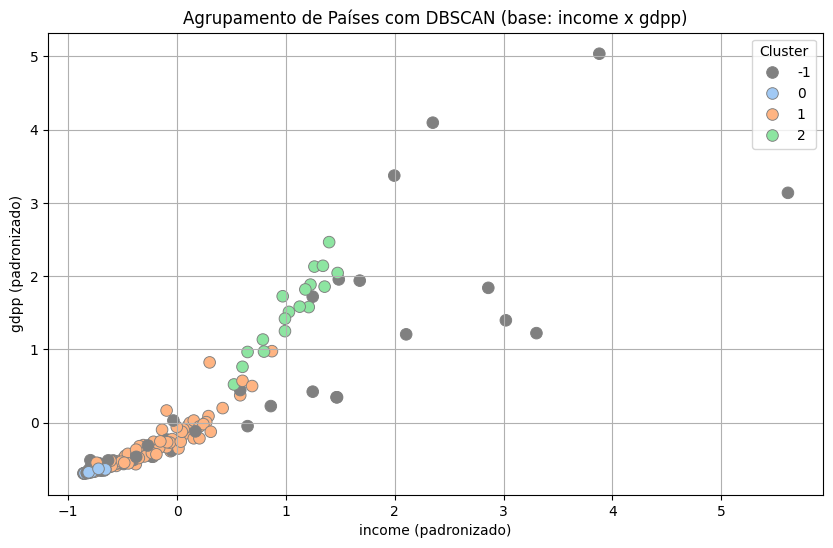

In [20]:
 
#Escolhe as duas variáveis principais
x_var = 'income'
y_var = 'gdpp'

#Cria um DataFrame com os dados padronizados e os rótulos do DBSCAN
X_plot = df_scaled[[x_var, y_var]].copy()
X_plot['Cluster_DBSCAN'] = df['Cluster_DBSCAN']

#Define as cores — outliers (-1) em cinza
palette = sns.color_palette("pastel", len(set(df['Cluster_DBSCAN'])) - (1 if -1 in df['Cluster_DBSCAN'].values else 0))
palette = ['gray'] + palette  # adiciona o cinza para os outliers primeiro

#Cria o gráfico
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=X_plot,
    x=x_var, 
    y=y_var,
    hue='Cluster_DBSCAN',
    palette=palette,
    s=70,
    edgecolor='gray'
)

#Personaliza o gráfico
plt.title("Agrupamento de Países com DBSCAN (base: income x gdpp)")
plt.xlabel(f"{x_var} (padronizado)")
plt.ylabel(f"{y_var} (padronizado)")
plt.legend(title="Cluster", loc='best')
plt.grid(True)
plt.show()


In [21]:
# Agrupar por cluster e calcular médias apenas dos clusters válidos (sem -1)
perfil_dbscan = df[df['Cluster_DBSCAN'] != -1].groupby('Cluster_DBSCAN').mean(numeric_only=True).round(2)

print("Perfis médios dos clusters DBSCAN (sem outliers):\n")
print(perfil_dbscan)


Perfis médios dos clusters DBSCAN (sem outliers):

                child_mort  exports  health  imports    income  inflation  \
Cluster_DBSCAN                                                              
0                    94.19    25.47    5.60    39.07   2039.22       7.86   
1                    20.94    40.21    6.39    46.70  12884.08       6.00   
2                     4.17    35.63   10.17    34.49  37338.89       1.36   

                life_expec  total_fer      gdpp  Cluster_KMeans  \
Cluster_DBSCAN                                                    
0                    59.40       5.34    811.74            1.00   
1                    73.18       2.19   7443.08            1.84   
2                    81.01       1.80  41150.00            0.00   

                Cluster_Hierarquico  Cluster_Medoid  
Cluster_DBSCAN                                       
0                              2.13            1.00  
1                              3.00            1.76  
2          

In [22]:
 

# Lista de clusters válidos (sem -1)
clusters_validos = [c for c in df['Cluster_DBSCAN'].unique() if c != -1]

print("\nPaís mais representativo (mais próximo da média) de cada cluster:\n")
for c in clusters_validos:
    # Subconjunto do cluster
    cluster_data = df[df['Cluster_DBSCAN'] == c]
    X_cluster = X_scaled[df['Cluster_DBSCAN'] == c]

    # Calcula a média do cluster
    centroid = X_cluster.mean(axis=0).reshape(1, -1)

    # Encontra o ponto mais próximo dessa média
    idx, _ = pairwise_distances_argmin_min(centroid, X_cluster)

    # Pega o nome do país correspondente
    country = cluster_data.iloc[idx[0]]['country']
    print(f"Cluster {c}: país mais representativo → {country}")



País mais representativo (mais próximo da média) de cada cluster:

Cluster 0: país mais representativo → Mozambique
Cluster 1: país mais representativo → El Salvador
Cluster 2: país mais representativo → United Kingdom


Perfeito! Aqui está essa última parte transformada em **Markdown**, no mesmo estilo das seções anteriores, organizada e clara:

---

## **Sensibilidade do K-Médias a Outliers**

* O **K-Médias** é sensível a **outliers** porque calcula os **centróides usando a média** das observações de cada grupo.
* Como a **média é facilmente influenciada por valores extremos**, **um único país com valores muito altos ou muito baixos** pode deslocar o centróide e distorcer o agrupamento.
* **Resumindo:** um ponto “fora da curva” pode puxar o centro do grupo para perto dele, fazendo com que países que não se parecem tanto sejam **erroneamente agrupados**.

---

## **Robustez do DBSCAN a Outliers**

* O **DBSCAN** é mais robusto porque **não depende de médias ou centróides**.
* Agrupa pontos **com base na densidade de vizinhos**:

  * Um ponto pertence a um cluster **somente se estiver cercado por vizinhos suficientes**.
  * Pontos sem vizinhos suficientes são marcados como **ruído (outliers)** e **não afetam a formação dos clusters**.

---

## **Clusters Identificados pelo DBSCAN**

### **Cluster 0 – Países em vulnerabilidade socioeconômica**

**País mais representativo:** 🇲🇿 Mozambique

* Mortalidade infantil: 94,19
* Renda per capita: 2.039
* Expectativa de vida: 59,40 anos
* Fertilidade: 5,34 filhos/mulher
* Inflação: 7,86%
* Exportações: 25,47% do PIB
* Importações: 39,07% do PIB
* Investimento em saúde: 5,60% do PIB
* PIB per capita: 812

**Análise:**
Este grupo representa países de **baixa renda**, com sérios desafios sociais e econômicos.
A **alta mortalidade infantil**, **baixa expectativa de vida** e **fertilidade elevada** indicam **fragilidade estrutural** e **baixo investimento em qualidade de vida**.
O **Mozambique** representa bem esse cluster, refletindo padrões médios de nações com economia dependente, **alta desigualdade** e **vulnerabilidade social**, comuns na África Subsaariana.

---

### **Cluster 1 – Economias emergentes / em desenvolvimento**

**País mais representativo:** 🇸🇻 El Salvador

* Mortalidade infantil: 20,94
* Renda per capita: 12.884
* Expectativa de vida: 73,18 anos
* Fertilidade: 2,19 filhos/mulher
* Inflação: 6,00%
* Exportações: 40,21% do PIB
* Importações: 46,70% do PIB
* Investimento em saúde: 6,39% do PIB
* PIB per capita: 7.443

**Análise:**
Este grupo representa países em **transição econômica**, com melhorias estruturais e **crescimento estável**, embora ainda apresentem **desigualdades**.
O **El Salvador** exemplifica bem países que saíram de um cenário de vulnerabilidade e se aproximam de **economias mais estáveis**, com avanços em **educação, saúde e exportações**, mas ainda enfrentando desafios de **renda e produtividade**.

---

### **Cluster 2 – Países Desenvolvidos**

**País mais representativo:** 🇬🇧 United Kingdom

* Mortalidade infantil: 4,17
* Renda per capita: 37.338
* Expectativa de vida: 81,01 anos
* Fertilidade: 1,80 filhos/mulher
* Inflação: 1,36%
* Exportações: 35,63% do PIB
* Importações: 34,49% do PIB
* Investimento em saúde: 10,17% do PIB
* PIB per capita: 41.150

**Análise:**
Este grupo representa países **desenvolvidos**, com **alta renda**, forte **investimento social** e **estabilidade econômica**.
O **Reino Unido** reflete bem o centro do grupo, combinando **alto poder aquisitivo**, **excelente infraestrutura de saúde** e **baixas taxas de mortalidade**, consolidando-se como uma **economia madura e de alto desenvolvimento humano**.


